#### IMPORTAR LIBRERIAS

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from gensim.models import KeyedVectors
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Concatenate
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import gensim.downloader as api

C:\Users\maria\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


#### LIMPIEZA DE LOS DATOS

In [4]:
df_true = pd.read_csv('True.csv')
df_fake = pd.read_csv('Fake.csv')

df_true['output'] = 'True'
df_fake['output'] = 'Fake'
df_true['text'] = df_true['text'].str.replace(r'^[^–\-]+[–\-]\s*', '', regex=True).str.lstrip()
df_true['title'] = df_true['title'].str.lstrip()
df_fake['title'] = df_fake['title'].str.lstrip()
df_fake['text'] = df_fake['text'].str.lstrip()

In [5]:
data = pd.concat([df_true, df_fake], ignore_index=True)
data.drop_duplicates()
data.head()

,title,text,subject,date,output
0,"As U.S. budget fight looms, Republicans flip t...",The head of a conservative Republican faction ...,politicsNews,"December 31, 2017",True
1,U.S. military to accept transgender recruits o...,Transgender people will be allowed for the fir...,politicsNews,"December 29, 2017",True
2,Senior U.S. Republican senator: 'Let Mr. Muell...,The special counsel investigation of links bet...,politicsNews,"December 31, 2017",True
3,FBI Russia probe helped by Australian diplomat...,Trump campaign adviser George Papadopoulos tol...,politicsNews,"December 30, 2017",True
4,Trump wants Postal Service to charge 'much mor...,President Donald Trump called on the U.S. Post...,politicsNews,"December 29, 2017",True


In [6]:
data['output'].value_counts()
data['output'].value_counts(normalize=True) * 100 #porcentaje

output
Fake    52.298543
True    47.701457
Name: proportion, dtype: float64

#### VECTORIZAR

In [8]:
# Extraer variables
X1 = data['title'].astype(str)
X2 = data['text'].astype(str)
y = np.array(data['output'])

In [9]:
# Tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X1 + " " + X2)

# Secuencias numéricas
sequences1 = tokenizer.texts_to_sequences(X1)
sequences2 = tokenizer.texts_to_sequences(X2)

# Padding
max_len = 5000
X1_padded = pad_sequences(sequences1, maxlen=max_len)
X2_padded = pad_sequences(sequences2, maxlen=max_len)

In [10]:
# Dividir
X1_train, X1_val, X2_train, X2_val, y_train, y_val = train_test_split(
    X1_padded, X2_padded, y, test_size=0.25, random_state=42)

# Convertir y a binario
y_train = np.where(y_train == "Fake", 0, 1).astype(np.float32)
y_val = np.where(y_val == "Fake", 0, 1).astype(np.float32)

In [11]:
# Carga automática del modelo preentrenado desde gensim
w2v_model = api.load("word2vec-google-news-300")

In [12]:
# Crear embedding matrix
embedding_dim = 300
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in w2v_model:
        embedding_matrix[i] = w2v_model[word]
    else:
        embedding_matrix[i] = np.random.normal(0, 0.1, embedding_dim)

# Capa embedding con pesos preentrenados
from tensorflow.keras.layers import Embedding
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False)

#### ENTRENAR MODELO

In [14]:
# Modelo
input1 = Input(shape=(max_len,))
embedding1 = embedding_layer(input1)
rnn1 = SimpleRNN(64)(embedding1)

input2 = Input(shape=(max_len,))
embedding2 = embedding_layer(input2)
rnn2 = SimpleRNN(64)(embedding2)


merged = Concatenate()([rnn1, rnn2])
merged = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(merged)
output = Dense(1, activation="sigmoid")(merged)

model = Model(inputs=[input1, input2], outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1)

checkpoint = ModelCheckpoint(
    'modelo_RNN_Word2Vec.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 5000)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 5000)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 5000, 300)         │      44,269,800 │ input_layer[0][0],         │
│                               │                           │                 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ simple_rnn (SimpleRNN)        │ (None, 64)                │          23,360 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ simple_rnn_1 (SimpleRNN)      │ (None, 64)                │          23,360 │ embedding[1][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 128)               │               0 │ simple_rnn[0][0],          │
│                               │                           │                 │ simple_rnn_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           8,256 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 1)                 │              65 │ dense[0][0]                │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 44,324,841 (169.09 MB)

 Trainable params: 55,041 (215.00 KB)

 Non-trainable params: 44,269,800 (168.88 MB)

In [15]:
# Entrenamiento
history = model.fit(
    [X1_train, X2_train],
    y_train,
    epochs=10,
    batch_size=256,
    validation_data=([X1_val, X2_val], y_val),
    callbacks=[early_stop, checkpoint],
    verbose=2)

Epoch 1/10

Epoch 1: val_loss improved from inf to 0.11496, saving model to modelo_RNN_Word2Vec.keras
132/132 - 827s - 6s/step - accuracy: 0.9363 - loss: 0.2293 - val_accuracy: 0.9797 - val_loss: 0.1150
Epoch 2/10

Epoch 2: val_loss improved from 0.11496 to 0.08334, saving model to modelo_RNN_Word2Vec.keras
132/132 - 968s - 7s/step - accuracy: 0.9822 - loss: 0.0942 - val_accuracy: 0.9835 - val_loss: 0.0833
Epoch 3/10

Epoch 3: val_loss improved from 0.08334 to 0.06478, saving model to modelo_RNN_Word2Vec.keras
132/132 - 1091s - 8s/step - accuracy: 0.9898 - loss: 0.0613 - val_accuracy: 0.9863 - val_loss: 0.0648
Epoch 4/10

Epoch 4: val_loss improved from 0.06478 to 0.05301, saving model to modelo_RNN_Word2Vec.keras
132/132 - 1053s - 8s/step - accuracy: 0.9927 - loss: 0.0419 - val_accuracy: 0.9869 - val_loss: 0.0530
Epoch 5/10

Epoch 5: val_loss improved from 0.05301 to 0.04329, saving model to modelo_RNN_Word2Vec.keras
132/132 - 1202s - 9s/step - accuracy: 0.9936 - loss: 0.0329 - val_ac

In [16]:
results = model.evaluate([X1_val, X2_val], y_val)
print(f"Test Loss: {results[0]}, Test Accuracy: {results[1]}")

351/351 ━━━━━━━━━━━━━━━━━━━━ 470s 1s/step - accuracy: 0.9915 - loss: 0.0323
Test Loss: 0.031838711351156235, Test Accuracy: 0.9922494292259216


#### VISUALIZAR RESULTADOS

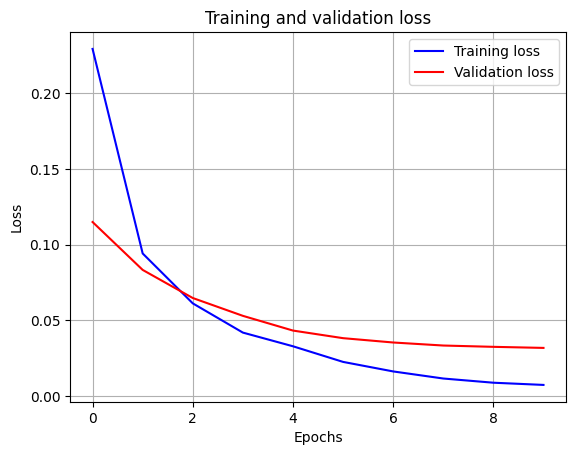

In [18]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], color='blue', label='Training loss')
plt.plot(history.history['val_loss'], color='red', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

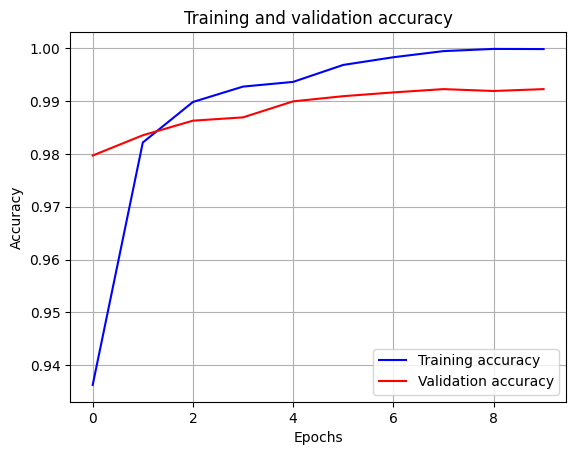

In [19]:
plt.plot(history.history['accuracy'], color='blue', label='Training accuracy')
plt.plot(history.history['val_accuracy'], color='red', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

351/351 ━━━━━━━━━━━━━━━━━━━━ 427s 1s/step


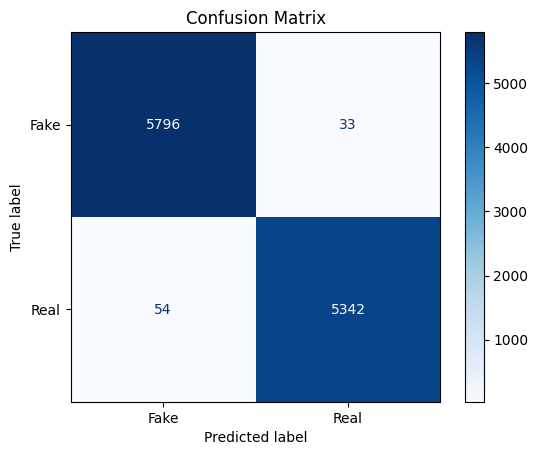

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
y_pred_prob = model.predict([X1_val, X2_val])
y_pred = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

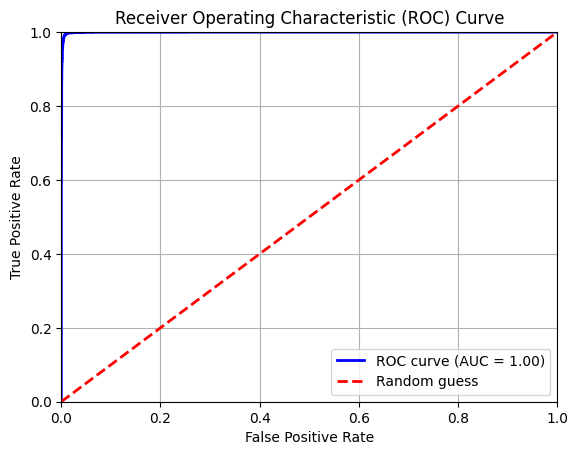

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
auc_score = roc_auc_score(y_val, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Comprobar el modelo

In [56]:
fake_title = "Breaking: Aliens Found Living Under the Eiffel Tower"
fake_body = (
    "In a bizarre twist straight out of a science fiction movie, an anonymous source has leaked classified documents "
    "allegedly revealing the existence of an alien base located beneath the Eiffel Tower in Paris. The source claims that "
    "during a routine maintenance check in early 2023, underground scanners picked up unexplained electromagnetic activity "
    "that led to the discovery of a hidden chamber. Inside, maintenance workers allegedly found strange equipment, symbols "
    "not of any known language, and even signs of biological organisms that emit light. The beings, reportedly resembling "
    "tall humanoid figures with elongated limbs, are said to have been living undetected for decades and use advanced "
    "technology to avoid human detection. Despite repeated inquiries from journalists and independent researchers, French "
    "government officials have refused to comment on the matter. Conspiracy theorists argue that world governments have "
    "known about extraterrestrial life for years and are now working together to suppress this new revelation. No physical "
    "evidence has yet been presented to the public, and mainstream scientists have dismissed the claims as a hoax. However, "
    "online forums and social media are buzzing with speculation, and some Parisians have reported unusual activity near the landmark at night."
)


In [58]:
real_title = "NASA Confirms Water Ice on the Moon"
real_body = (
    "NASA has officially confirmed the existence of water ice on the surface of the Moon, "
    "marking a significant breakthrough in lunar exploration. The discovery was made using data "
    "collected by the Moon Mineralogy Mapper, an instrument aboard India's Chandrayaan-1 spacecraft. "
    "According to scientists, water ice was detected in the darkest and coldest parts of the lunar poles, "
    "where sunlight never reaches and temperatures are permanently below freezing. This evidence supports "
    "the idea that the Moon could one day support human life, as water is a critical resource not only for "
    "sustaining astronauts but also for producing fuel and oxygen. The findings have sparked renewed interest "
    "in future missions to the Moon, including NASA’s Artemis program, which aims to return astronauts to the "
    "lunar surface. The availability of water could greatly reduce the cost and complexity of these missions by "
    "allowing astronauts to extract resources directly on-site. NASA officials have stated that more missions and "
    "studies will be conducted to further analyze the ice deposits and determine how accessible they are for future use."
)


In [60]:
def predict_news(title, body):
    title_seq = tokenizer.texts_to_sequences([title])
    body_seq = tokenizer.texts_to_sequences([body])

    title_pad = pad_sequences(title_seq, maxlen=max_len)
    body_pad = pad_sequences(body_seq, maxlen=max_len)

    prediction = model.predict([title_pad, body_pad])
    prob = prediction[0][0]
    pred_class = int(prob > 0.5)

    print(f"Title: {title}")
    print(f"Predicted class: {pred_class} (Probability: {prob:.4f})\n")


predict_news(real_title, real_body)
predict_news(fake_title, fake_body)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Title: NASA Confirms Water Ice on the Moon
Predicted class: 1 (Probability: 0.9960)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Title: Breaking: Aliens Found Living Under the Eiffel Tower
Predicted class: 0 (Probability: 0.2869)

